## Calibrating SoilNet for Conformal Horizon Classification

In [1]:
import os
os.chdir('../../../')
!pwd

/mnt/KInsektDaten/teo


In [2]:
import sys
sys.path.append('./BGR')
import numpy as np
import torch
import matplotlib.pyplot as plt
from bgr.soil.data.horizon_tabular_data import HorizonDataProcessor
from bgr.soil.utils import extract_segments

In [3]:
dataprocessor = HorizonDataProcessor(label_embeddings_path='./BGR/label_embeddings/all_horizons_embeddings_thirds.pickle')
df = dataprocessor.load_processed_data()

train_df, val_df, calib_df, test_df = dataprocessor.multi_label_stratified_shuffle_split_calibrated(df, train_val_calib_test_frac=[0.6, 0.2, 0.1, 0.1], random_state=2025)

In [4]:
#soilnet_path = './BGR/models/end2ends/linear_decreasing_teacher/end2end_lstm_resnet_embed_2025-05-13_12-14-11/model.pt'
soilnet_path = './BGR/models/end2ends/linear_decreasing_teacher/end2end_lstm_resnet_2025-05-13_18-05-30/model.pt'
output_shape = np.shape(dataprocessor.embeddings_dict['embedding']) # dimension of embeddings or number of classes
device = 'cuda:0'

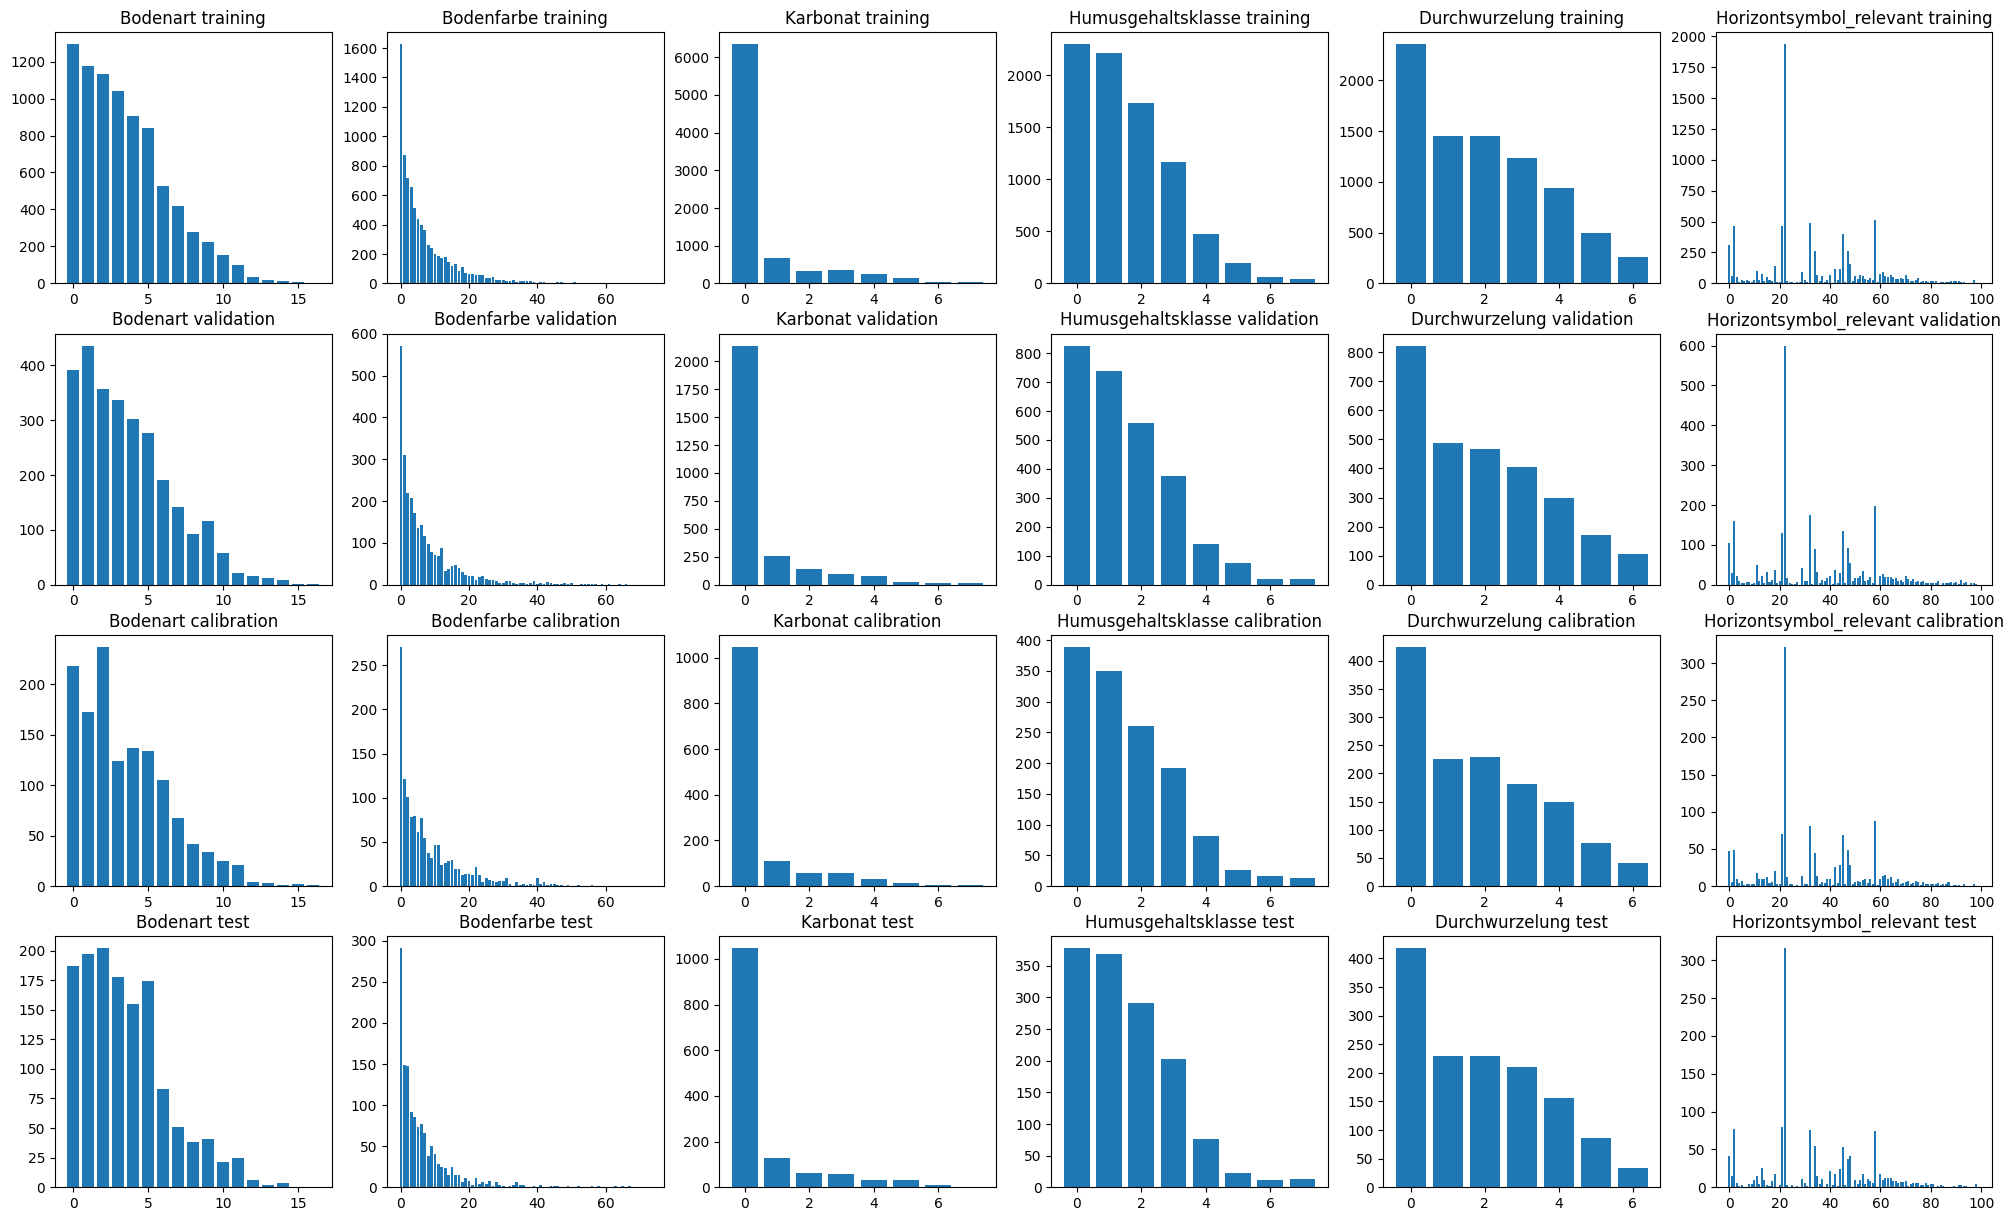

In [5]:
plt.figure(figsize=(25, 15))
for i, tab_feature in enumerate(list(dataprocessor.stratified_split_targets)):
    if tab_feature == 'Horizontsymbol_relevant':
        num_cls = output_shape[0]
    else:
        num_cls = dataprocessor.tabulars_output_dim_dict[tab_feature]

    counts_train = train_df[tab_feature].explode().value_counts().reindex(np.arange(num_cls), fill_value=0)
    counts_val   = val_df[tab_feature].explode().value_counts().reindex(np.arange(num_cls), fill_value=0)
    counts_calib = calib_df[tab_feature].explode().value_counts().reindex(np.arange(num_cls), fill_value=0)
    counts_test  = test_df[tab_feature].explode().value_counts().reindex(np.arange(num_cls), fill_value=0)

    plt.subplot(4, 6, i + 1)
    plt.bar(list(range(num_cls)), list(counts_train.values))
    plt.title(tab_feature + ' training')
    plt.subplot(4, 6, i + 7)
    plt.bar(list(range(num_cls)), list(counts_val.values))
    plt.title(tab_feature + ' validation')
    plt.subplot(4, 6, i + 13)
    plt.bar(list(range(num_cls)), list(counts_calib.values))
    plt.title(tab_feature + ' calibration')
    plt.subplot(4, 6, i + 19)
    plt.bar(list(range(num_cls)), list(counts_test.values))
    plt.title(tab_feature + ' test')
plt.show()

In [6]:
from bgr.soil.modelling.soilnet import SoilNet_LSTM

soilnet = SoilNet_LSTM(
            # Parameters for image encoder, geotemp encoder and depth predictor:
            geo_temp_input_dim        = len(dataprocessor.geotemp_img_infos) - 2, # without index and img path
            geo_temp_output_dim       = 256,
            image_encoder_output_dim  = 512,
            max_seq_len               = 8,
            stop_token                = 1.0,
            depth_rnn_hidden_dim      = 256,
            img_patch_size            = 512,
            segments_random_patches   = True, # True = use ResNet, False = use custom CNN
            num_patches_per_segment   = 8,
            segment_random_patch_size = 224,
            
            # Parameters for tabular predictors:
            tabular_output_dim_dict    = dataprocessor.tabulars_output_dim_dict,
            segment_encoder_output_dim = 512,
            tab_rnn_hidden_dim         = 1024,
            tab_num_lstm_layers        = 2,
            
            # Parameters for horizon predictor:
            segments_tabular_output_dim = 256,
            embedding_dim               = output_shape[1] if 'embed' in soilnet_path else output_shape[0],
            
            # Parameters for the model:
            teacher_forcing_stop_epoch  = -1, # no teacher forcing when doing only inference
            teacher_forcing_approach    = 'linear'
        )

soilnet.load_state_dict(torch.load(soilnet_path, map_location=torch.device(device)))

<All keys matched successfully>

In [7]:
from bgr.soil.data.datasets import ImageTabularEnd2EndDataset
import torchvision.transforms as transforms

subsets = []
for subset_df in [calib_df, test_df]:
    subset = ImageTabularEnd2EndDataset(
        dataframe=subset_df,
        normalize=transforms.Compose([
                transforms.ToTensor(),
                transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]), # Normalize with ImageNet statistics
            ]),
        label_column='Horizontsymbol_relevant',
        geotemp_columns=dataprocessor.geotemp_img_infos[:-1], # without img path
        tab_num_columns=['Steine'],
        tab_categ_columns={key : value 
                for key, value in dataprocessor.tabulars_output_dim_dict.items() 
                    if key in [
                            'Bodenart',
                            'Bodenfarbe',
                            'Karbonat',
                            'Humusgehaltsklasse',
                            'Durchwurzelung'
                        ]
            }
    )
    subsets.append(subset)

calib_dataset, test_dataset = subsets

In [8]:
batch_size = 8
calib_loader = calib_dataset.to_dataloader(batch_size = batch_size, shuffle = False, num_workers = 4)
test_loader  = test_dataset.to_dataloader(batch_size = batch_size,  shuffle = False, num_workers = 4)

In [9]:
def soilnet_inference(data_loader, model, device):
    
    model.to(device)
    model.eval()
    
    all_pred_depths, all_true_depths   = [], []
    all_pred_logits, all_true_hor_inds = [], []
    segment_geotemp_features = []
    for batch in data_loader:
        padded_images, image_mask, geotemp_features, padded_true_depths, padded_segments_tabulars_labels, padded_true_horizon_indices = batch
        padded_images, image_mask, geotemp_features, padded_true_depths, padded_segments_tabulars_labels, padded_true_horizon_indices = (
            padded_images.to(device),
            image_mask.to(device),
            geotemp_features.to(device),
            padded_true_depths.to(device),
            padded_segments_tabulars_labels.to(device),
            padded_true_horizon_indices.to(device)
        )
        
        with torch.no_grad():
            
            # Mask for valid indices
            mask = padded_true_horizon_indices != -1
            
            ### Predictions for all (sub)tasks
            padded_pred_depths, padded_pred_tabulars, padded_pred_logits = model(
                padded_images,
                image_mask,
                geotemp_features[:, 1:], # 'index' column not used in model
                #padded_true_depths,             # use predicted depths when not training 
                #padded_segments_tabulars_labels # use predicted tabulars when not training
            )
            
            # Store predicted horizon logits and true indices
            pred_logits = padded_pred_logits.view(-1, padded_pred_logits.size(-1))[mask.view(-1)]  # Apply mask
            all_pred_logits.append(pred_logits.cpu().numpy())
            
            true_horizon_indices = padded_true_horizon_indices.view(-1)[padded_true_horizon_indices.view(-1) != -1]
            all_true_hor_inds.append(true_horizon_indices.cpu().numpy())
            
            # Store predicted and true depths
            all_pred_depths.append(padded_pred_depths.cpu().numpy())
            all_true_depths.append(padded_true_depths.cpu().numpy())
            
            ### Store concatenated seg_geotemp features to train the residual predictor u(x) for the adaptive conformal depth regression
            # Crop image to segments
            segments = extract_segments(padded_images, image_mask, padded_pred_depths,
                                        soilnet.segments_random_patches, soilnet.patch_cnn_segment_size, 
                                        soilnet.num_patches_per_segment, soilnet.segment_random_patch_size, 
                                        soilnet.stop_token, soilnet.max_seq_len)
            batch_size, num_segments, num_patches, C, H, W = segments.shape
            # Encode each segment individually
            segment_features_list = []
            for i in range(num_segments):
                segment_patches = segments[:, i, :, :, :, :] # One additional dimension for the random patches
                segment_features = soilnet.segment_encoder(segment_patches)
                
                segment_features_list.append(segment_features)
            segment_features = torch.stack(segment_features_list, dim=1)
            
            # Replicate geo_temp_features for each segment
            geo_temp_features = soilnet.geo_temp_encoder(geotemp_features[:, 1:])
            geo_temp_features = geo_temp_features.unsqueeze(1).repeat(1, num_segments, 1)
            
            segment_geotemp_features.append( torch.cat([segment_features, geo_temp_features], dim=-1).cpu().numpy() )
            
    return segment_geotemp_features, all_pred_depths, all_true_depths, all_pred_logits, all_true_hor_inds

In [10]:
import torch.nn as nn

class ResidualPredictor(nn.Module):
    def __init__(self, input_dim, hidden_dim=64):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim//2),
            nn.ReLU(),
            nn.Linear(hidden_dim//2, 1),
            nn.Softplus() # ensure output is positive
        )

    def forward(self, x):
        return self.mlp(x).squeeze(-1)

In [11]:
# Inference on the calibration set
segment_geotemp_features_calib, all_pred_depths_calib, \
    all_true_depths_calib, all_pred_logits_calib, all_true_hor_inds_calib = soilnet_inference(calib_loader, soilnet, device)

In [12]:
# Inference on the test set
segment_geotemp_features_test, all_pred_depths_test, \
    all_true_depths_test, all_pred_logits_test, all_true_hor_inds_test = soilnet_inference(test_loader, soilnet, device)

### Calibrate Task 1

In [13]:
# Concatenate depths
all_pred_depths_calib = np.concatenate(all_pred_depths_calib, axis=0)
print(all_pred_depths_calib.shape)
all_pred_depths_test = np.concatenate(all_pred_depths_test, axis=0)
print(all_pred_depths_test.shape)

all_true_depths_calib = np.concatenate(all_true_depths_calib, axis=0)
print(all_true_depths_calib.shape)
all_true_depths_test = np.concatenate(all_true_depths_test, axis=0)
print(all_true_depths_test.shape)

(335, 8)
(335, 8)
(335, 8)
(335, 8)


In [14]:
# Unbatch seg. geotemp. features
segment_geotemp_list_calib = [item for sublist in segment_geotemp_features_calib for item in sublist]
print(len(segment_geotemp_list_calib))
segment_geotemp_list_test = [item for sublist in segment_geotemp_features_test for item in sublist]
print(len(segment_geotemp_list_test))

335
335


In [15]:
def trim_concat(true_depths, pred_depths, segment_geotemp_list):
    trimmed_true_depths = []
    # Remove trailing 1.0's, keep one if present
    for sublist in true_depths.tolist():
        i = len(sublist) - 1
        while i > 0 and sublist[i] == 1.0 and sublist[i-1] == 1.0:
            i -= 1
        trimmed_true_depths.append(sublist[:i+1])
        
    # Remove stop tokens from predicted depths as well, inaccordance with the trimmed true depths
    trimmed_pred_depths = []
    for i in range(len(pred_depths)):
        trimmed_pred_depths.append(pred_depths[i][:len(trimmed_true_depths[i])].tolist())
        
    # Unroll the list of lists
    trimmed_true_depths_stacked = torch.tensor([item for sublist in trimmed_true_depths for item in sublist])
    trimmed_pred_depths_stacked = torch.tensor([item for sublist in trimmed_pred_depths for item in sublist])
    
    # Remove input paddings for the stop tokens
    trimmed_segment_geotemp_list = []
    for i in range(len(segment_geotemp_list)):
        trimmed_segment_geotemp_list.append(segment_geotemp_list[i][:len(trimmed_true_depths[i])].tolist())
        
    # Concatenate the (uneven) lists
    segment_geotemp_concat = torch.tensor(np.concatenate(trimmed_segment_geotemp_list, axis=0)).to(torch.float32)
    
    return trimmed_true_depths_stacked, trimmed_pred_depths_stacked, segment_geotemp_concat

In [16]:
# Trim true and predicted depths from trailing stop tokens and stack them
trimmed_true_depths_stacked_calib, \
    trimmed_pred_depths_stacked_calib, \
        segment_geotemp_concat_calib = trim_concat(all_true_depths_calib, all_pred_depths_calib, segment_geotemp_list_calib)
trimmed_true_depths_stacked_test, \
    trimmed_pred_depths_stacked_test, \
        segment_geotemp_concat_test   = trim_concat(all_true_depths_test, all_pred_depths_test, segment_geotemp_list_test)
print(len(trimmed_true_depths_stacked_calib))
print(len(trimmed_pred_depths_stacked_calib))
print(len(segment_geotemp_concat_calib))
print(len(trimmed_true_depths_stacked_test))
print(len(trimmed_pred_depths_stacked_test))
print(len(segment_geotemp_concat_test))

1327
1327
1327
1364
1364
1364


In [17]:
# Compute conformity scores as s_x = |true_depth - pred_depth_x|
conf_scores_depths_calib = torch.abs(trimmed_true_depths_stacked_calib - trimmed_pred_depths_stacked_calib).to(torch.float32)
print(conf_scores_depths_calib.shape)
conf_scores_depths_test = torch.abs(trimmed_true_depths_stacked_test - trimmed_pred_depths_stacked_test).to(torch.float32)
print(conf_scores_depths_test.shape)

torch.Size([1327])
torch.Size([1364])


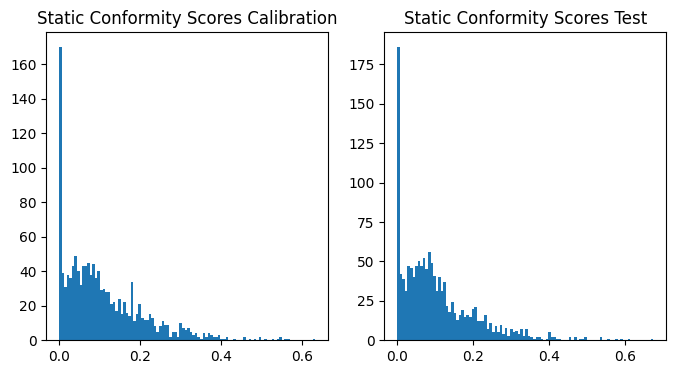

In [18]:
plt.figure(figsize=(8,4))
plt.subplot(121)
plt.hist(conf_scores_depths_calib.numpy(), bins=100)
plt.title('Static Conformity Scores Calibration')
plt.subplot(122)
plt.hist(conf_scores_depths_test.numpy(), bins=100)
plt.title('Static Conformity Scores Test');

In [19]:
from torch.utils.data import TensorDataset, DataLoader
resid_dataset_calib = TensorDataset(segment_geotemp_concat_calib, conf_scores_depths_calib)
resid_loader_calib  = DataLoader(resid_dataset_calib, batch_size=batch_size, shuffle=False)
# Note: don't shuffle, so that the predicted residuals match the conformity scores

resid_dataset_test = TensorDataset(segment_geotemp_concat_test, conf_scores_depths_test)
resid_loader_test  = DataLoader(resid_dataset_test, batch_size=batch_size, shuffle=False)

In [20]:
# Initialize residual model
residual_model = ResidualPredictor(input_dim=segment_geotemp_concat_calib.shape[1])
# Load model if pretrained
residual_model.load_state_dict(torch.load('./BGR/models/conformal/residual_mlp_softplus.pt'))

<All keys matched successfully>

Epoch 0: Train Loss = 0.0328, Validation Loss = 0.0104
Epoch 1: Train Loss = 0.0105, Validation Loss = 0.0103
Epoch 2: Train Loss = 0.0103, Validation Loss = 0.0101
Epoch 3: Train Loss = 0.0101, Validation Loss = 0.0099
Epoch 4: Train Loss = 0.0099, Validation Loss = 0.0098
Epoch 5: Train Loss = 0.0097, Validation Loss = 0.0097
Epoch 6: Train Loss = 0.0095, Validation Loss = 0.0096
Epoch 7: Train Loss = 0.0093, Validation Loss = 0.0096
Epoch 8: Train Loss = 0.0092, Validation Loss = 0.0096
Epoch 9: Train Loss = 0.0090, Validation Loss = 0.0096


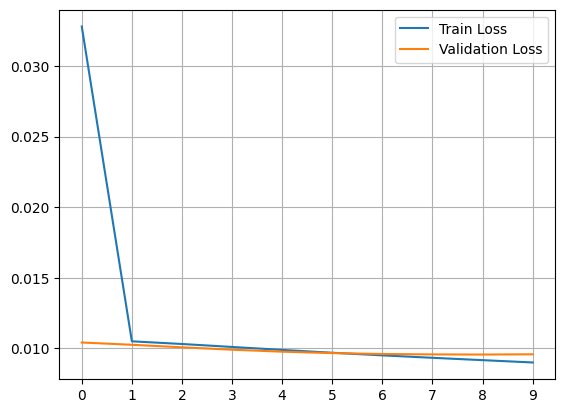

In [40]:
optimizer = torch.optim.Adam(residual_model.parameters(), lr=1e-4)
criterion = nn.MSELoss()
train_loss_hist, val_loss_hist = [], []
num_epochs = 10

# Training loop (on the calibration set)
for epoch in range(num_epochs):
    residual_model.train()
    total_train_loss = 0.0
    for x_batch, r_batch in resid_loader_calib:
        optimizer.zero_grad()
        r_hat = residual_model(x_batch)
        loss = criterion(r_hat, r_batch)
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item()
    avg_train_loss = total_train_loss / len(resid_loader_calib)
    train_loss_hist.append(avg_train_loss)
    
    # Evaluate on test set
    residual_model.eval()
    total_val_loss = 0.0
    with torch.no_grad():
        for x_batch, r_batch in resid_loader_test:
            r_hat = residual_model(x_batch)
            loss = criterion(r_hat, r_batch)
            total_val_loss += loss.item()
    avg_val_loss = total_val_loss / len(resid_loader_test)
    val_loss_hist.append(avg_val_loss)
    print(f"Epoch {epoch}: Train Loss = {avg_train_loss:.4f}, Validation Loss = {avg_val_loss:.4f}")   
    
plt.plot(train_loss_hist, label='Train Loss')
plt.plot(val_loss_hist, label='Validation Loss')
plt.xticks(np.arange(num_epochs))
plt.grid()
plt.legend();

# Save residual model weights
torch.save(residual_model.state_dict(), './BGR/models/conformal/residual_mlp_softplus.pt')

In [21]:
# Predict the residuals on the calibration set to rescale the conformity scores
pred_residuals_calib = residual_model(segment_geotemp_concat_calib)
print(len(pred_residuals_calib))

# Also on the test set for inference later
pred_residuals_test = residual_model(segment_geotemp_concat_test)
print(len(pred_residuals_test))

1327
1364


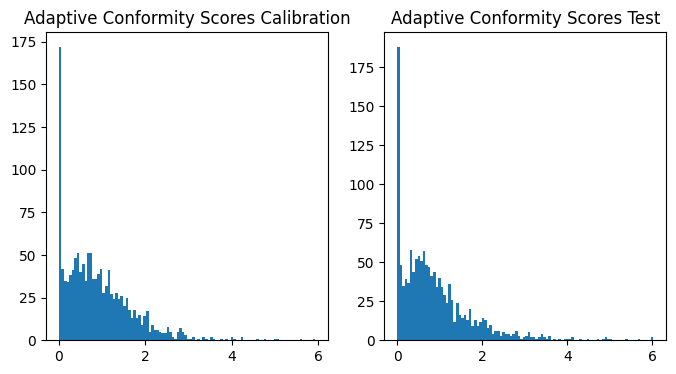

In [22]:
plt.figure(figsize=(8,4))
plt.subplot(121)
plt.hist((conf_scores_depths_calib / pred_residuals_calib).detach().numpy(), bins=100)
plt.title('Adaptive Conformity Scores Calibration')
plt.subplot(122)
plt.hist((conf_scores_depths_test / pred_residuals_test).detach().numpy(), bins=100)
#plt.xlim([0, 5])
plt.title('Adaptive Conformity Scores Test');

In [23]:
# Compute quantile on calibration set
qhat_depth = torch.quantile(conf_scores_depths_calib / pred_residuals_calib, 0.9).detach().numpy()
qhat_depth
# Note: 2*qhat_depth*pred_residual_x = width of the confidence interval centered at the predicted depth 

array(1.9267484, dtype=float32)

In [24]:
# For comparison: is the quantile on the test set also roughly around the quantile on the calib. set?
qhat_depth_test = torch.quantile(conf_scores_depths_test / pred_residuals_test, 0.9).detach().numpy()
qhat_depth_test

array(2.0049913, dtype=float32)

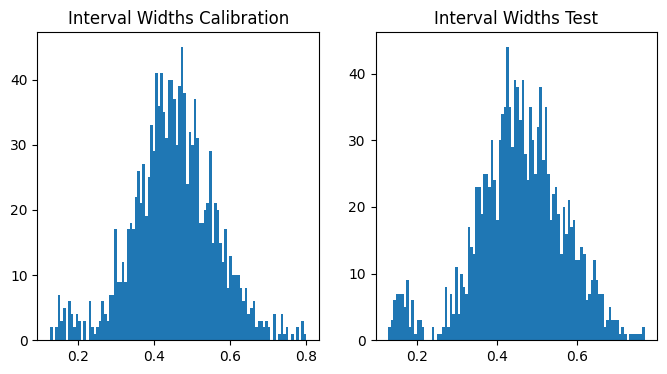

In [25]:
plt.figure(figsize=(8,4))
plt.subplot(121)
plt.hist(2 * qhat_depth * pred_residuals_calib.detach().numpy(), bins=100)
plt.title('Interval Widths Calibration')
plt.subplot(122)
plt.hist(2 * qhat_depth * pred_residuals_test.detach().numpy(), bins=100)
plt.title('Interval Widths Test');

#### Visualize one example

In [47]:
ex_ind = 0

# Get index of the stop token of the chosen example
stop_token_occurrences = (trimmed_true_depths_stacked_test == 1.0).nonzero(as_tuple=True)[0]
top_ind, bottom_ind = stop_token_occurrences[ex_ind-1]+1 if ex_ind > 0 else 0, stop_token_occurrences[ex_ind]+1
top_ind, bottom_ind

(0, tensor(6))

In [48]:
# Retrieve image from batched dataloader
ex_num_batches = ex_ind // batch_size
ex_samples_last_batch = ex_ind % batch_size
for i, batch in enumerate(test_loader):
    if i == ex_num_batches:
        padded_images, image_masks, _, _, _, _ = batch
        padded_image, image_mask = padded_images[ex_samples_last_batch].to(device), image_masks[ex_samples_last_batch].to(device)
        break

In [49]:
# Unpad image
_, row_inds, col_inds = np.where(image_mask.cpu().numpy() == True)
row_ind, col_ind = max(row_inds), max(col_inds)
orig_img = padded_image[:, :row_ind, :col_ind]
orig_img.shape

torch.Size([3, 3321, 1804])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


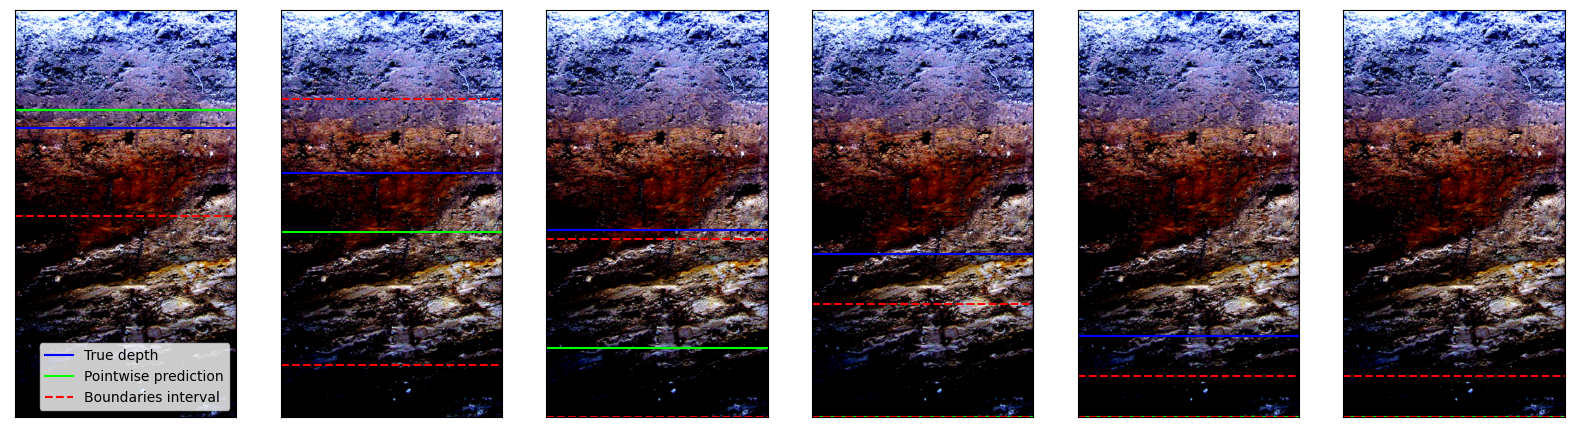

In [50]:
# Plot prediction intervals for all pointwise predicted markers
plt.figure(figsize=(20, 14))
img_height = orig_img.shape[1]
eps = 0.001
for i, ind in enumerate(range(top_ind, bottom_ind)):
    plt.subplot(1, (bottom_ind-top_ind).tolist(), i+1)
    plt.imshow(orig_img.permute(1, 2, 0).cpu().numpy())
    
    pred_depth = np.min((trimmed_pred_depths_stacked_test[ind], 1.0-eps)) # subtract an epsilon here to avoid plot artifacts at the final prediction
    true_depth = np.min((trimmed_true_depths_stacked_test[ind], 1.0-eps))
    
    # Get the confidence interval width
    lower = np.max((eps, pred_depth - qhat_depth * pred_residuals_test[ind].detach().numpy()))
    upper = np.min((pred_depth + qhat_depth * pred_residuals_test[ind].detach().numpy(), 1.0-eps))

    # Convert normalized depths to pixel coordinates
    plt.axhline(y=true_depth * img_height, color='blue', linestyle='-')
    plt.axhline(y=pred_depth * img_height, color='lime', linestyle='-')
    plt.axhline(y=lower * img_height, color='red', linestyle='--')
    plt.axhline(y=upper * img_height, color='red', linestyle='--')
    if i == 0: plt.legend(['True depth', 'Pointwise prediction', 'Boundaries interval'], loc='lower right')
    plt.xticks([]);plt.yticks([])
plt.show()

### Calibrate Task 3

In [13]:
# Concatenate pred. logits and true horizon indexes
all_pred_logits_calib = torch.from_numpy(np.concatenate(all_pred_logits_calib, axis=0))
print(all_pred_logits_calib.shape)
all_pred_logits_test = torch.from_numpy(np.concatenate(all_pred_logits_test, axis=0))
print(all_pred_logits_test.shape)

all_true_hor_inds_calib = torch.from_numpy(np.concatenate(all_true_hor_inds_calib, axis=0))
print(all_true_hor_inds_calib.shape)
all_true_hor_inds_test = torch.from_numpy(np.concatenate(all_true_hor_inds_test, axis=0))
print(all_true_hor_inds_test.shape)

torch.Size([1327, 100])
torch.Size([1364, 100])
torch.Size([1327])
torch.Size([1364])


In [14]:
# Apply softmax on pred. logits (in Pytorch, the CE loss applies softmax itself on the output layer)
import torch.nn.functional as F

all_pred_probs_calib = F.softmax(all_pred_logits_calib, dim=1)
print(all_pred_probs_calib.shape)
all_pred_probs_test = F.softmax(all_pred_logits_test, dim=1)
print(all_pred_probs_test.shape)

torch.Size([1327, 100])
torch.Size([1364, 100])


In [15]:
# Get probabilities of the true class
prob_true_class_calib = all_pred_probs_calib[torch.arange(len(all_true_hor_inds_calib)), all_true_hor_inds_calib]
print(prob_true_class_calib.shape)
prob_true_class_test = all_pred_probs_test[torch.arange(len(all_true_hor_inds_test)), all_true_hor_inds_test]
print(prob_true_class_test.shape)

torch.Size([1327])
torch.Size([1364])


In [16]:
# Compute quantile on conformity scores: 1 - softmax(f(x))_true 
qhat_horizon = torch.quantile(1 - prob_true_class_calib, 0.90) # apply sample correction (n+1)/n ?
qhat_horizon

tensor(0.9941)

In [55]:
# FOr comparison: quantile on the test set
# Compute quantile on conformity scores: 1 - softmax(f(x))_true 
qhat_horizon_test = torch.quantile(1 - prob_true_class_test, 0.90) # apply sample correction (n+1)/n ?
qhat_horizon_test

tensor(0.9942)

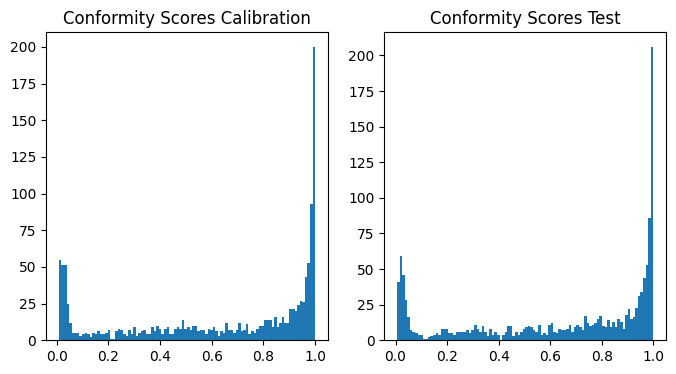

In [19]:
plt.figure(figsize=(8,4))
plt.subplot(121)
plt.hist((1 - prob_true_class_calib).numpy(), bins=100)
plt.title('Conformity Scores Calibration')
plt.subplot(122)
plt.hist((1 - prob_true_class_test).numpy(), bins=100)
plt.title('Conformity Scores Test');

In [22]:
# Predict label sets on the test set
test_prediction_sets = (1 - all_pred_probs_test <= qhat_horizon) 
print(test_prediction_sets.shape)
test_prediction_sets

torch.Size([1364, 100])


tensor([[False, False, False,  ..., False, False, False],
        [False, False, False,  ..., False, False, False],
        [ True,  True,  True,  ..., False, False, False],
        ...,
        [False, False, False,  ..., False, False, False],
        [False, False, False,  ..., False, False, False],
        [ True, False,  True,  ..., False, False, False]])

In [23]:
# Get the mapping from index to label
horizon_labels = dataprocessor.embeddings_dict['ind2label']

# For each row in test_prediction_sets, get the list of labels where the prediction set is True
predicted_label_lists = [
    [horizon_labels[i] for i, is_in_set in enumerate(row) if is_in_set]
    for row in test_prediction_sets.cpu().numpy()
]

In [25]:
for i, pred_sets in enumerate(predicted_label_lists):
    if i == 20: break
    print(pred_sets)

['Ap']
['Ap', 'Bv', 'M.', 'Sw-Bv', 'Al-Bv']
['ilC', 'Ael', 'Sd', 'Cv', 'Bhv', 'Go', 'Ap', 'Bv', 'lC', 'M.', 'Sw', 'Bt', 'Btv', 'Al', 'Sw-Bv', 'Bv-ilC', 'Bv-Sw', 'Bv-Cv', 'Al-Bv', 'Sd-Bt']
['ilC', 'Sd', 'Cv', 'Go', 'Bv', 'elC', 'lC', 'Sw', 'Bt', 'Btv', 'Sw-Bv', 'Bv-ilC', 'Bv-Sw', 'Bt-Sd', 'Bv-Cv', 'Sd-ilC', 'Al-Bv', 'Sd-Bt', 'Ael-Bt', 'Sd-Bv']
['ilC', 'Sd', 'Cv', 'Go', 'Bv', 'elC', 'lC', 'Sw', 'Bt', 'Btv', 'Bv-ilC', 'Bt-Sd', 'Bv-Cv', 'Sd-ilC', 'Sd-Bt', 'Go-ilC', 'Sd-Bv']
['ilC', 'Sd', 'C.', 'Cv', 'Gro', 'Go', 'Bv', 'elC', 'lC', 'Cj', 'Gr', 'Gor', 'Sw', 'Bt', 'Btv', 'Bv-ilC', 'Bt-Sd', 'Bv-Cv', 'Sd-ilC', 'Sd-Bt', 'Go-ilC', 'Sd-Bv']
['Ap', 'Ah']
['Ael', 'Bhv', 'Bvt', 'Ap', 'Acp', 'Bv', 'M.', 'Bt', 'Btv', 'Al', 'Sw-Bv', 'Bv-ilC', 'Al-Bv', 'Sw-Al', 'Sd-Bt', 'Sw-Ap', 'Bv-Ael']
['ilC', 'Ael', 'Sd', 'Cv', 'Bhv', 'Bvt', 'Bv', 'lC', 'Sw', 'Bt', 'Btv', 'Al', 'Sw-Bv', 'Bv-ilC', 'Bv-Sw', 'Bt-Sd', 'Bv-Cv', 'Al-Sw', 'Al-Bv', 'Sw-Al', 'Sd-Bt', 'Ael-Bt', 'Bv-Ael', 'Bv-Al', 'Al-Bt']
['ilC', 'Ael', 'Sd', 

### Conformal Predictions on Test Set

In [31]:
label_budget = 100 # how many oracle questions can we ask per task
thresh_depths = 0.25 # ask oracle, if the width of the confidence intervall is larger than a quarter of the image
thresh_horizons = 5 # ask oracle, if the prediction set has more than 5 classes